<style>
/* Enable wrapping of long code lines */
code, pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
    overflow-wrap: break-word !important;
}
</style>

# Exploratory Data Analysis (EDA) for Truth Seeker Model Dataset


In [ ]:
Dataset Column Information:
--------------------------------------

---Features_For_Traditional_ML_Techniques---

majority_target - Truth value of the tweet
statement - Headline of a new article
BinaryNumTarget - Binary representation of the statement's truth value (1 = True / 0 = False)
tweet - twitter posts related to the associated manual keywords
unique_count - number of unique, complex words.
present_verb - number of present tense verbs.
followers_count - number of followers.
total_count - total number of words.
past_verb number of past tense verbs.
friends_count - number of friends.
ORG_percent - Percent of text including spaCy ORG tags.
adjectives - number of adjectives.
favourites_count - number of favorites across all tweets.
NORP_percent - Percent of text including spaCy NORP tags.
pronouns - number of pronouns.
statuses_count - number of tweets.
GPE_percent - Percent of text including spaCy GPE tags.
TO’s - number of to usages.
listed_count - number of tweets the user has in lists.
PERSON_percent - Percent of text including spaCy PERSON tags.
determiners - number of determiners.
mentions - number of times the user was mentioned.
MONEY_percent - Percent of text including spaCy MONEY tags.
conjunctions - number of conjunctions.
quotes - number of times the user has been quote tweeted.
DATA_percent - Percent of text including spaCy DATA tags.
dots - number of (.) used.
replies - number of replies the user has.
CARDINAL_percent Percent of text including spaCy CARDINAL tags.
exclamations - number of (!) used.
retweets - number of retweets the user has.
PERCENT_percent - Percent of text including spaCy PERCENT tags.
question - number of (?) used.
favourites - number of favourites the user has.
ORDINAL_percent - Percent of text including spaCy ORDINAL tags.
ampersand - number of (&) used. 
hashtags number of hashtags (#) the user has used.
FAC_percent - Percent of text including spaCy FAC tags.
capitals - Number of capitalized letters.
URLs - number of URLs the user has posted.
LAW_percent - Percent of text including spaCy LAW tags.
quotes - number of quotation marks ("") used.
BotScoreBinary - Binary score whether the user is considered a bot or not.
PRODUCT_percent - Percent of text including spaCy PRODUCT tags.
digits - number of digits (0-9) used.
cred - credibility score.
EVENT_percent - Percent of text including spaCy EVENT tags. 
long_word_freq - number of long words.
normalized_influence - influence score the user has, normalized.
TIME_percent - Percent of text including spaCy TIME tags.
short_word_freq - number of short words.
LOC_percent - Percent of text including spaCy LOC tags.
ORG_percent - Percent of text including spaCy ORG tags.
WORK_OF_ART_percent - Percent of text including spaCy WOA tags.
QUANTITY_percent - Percent of text including spaCy QUANTITY tags.
LANGUAGE_percent - Percent of text including spaCy LANGUAGE tags.
Max Word - length of the longest word in the sentence.
Min Word - length of the shortest word in the sentence.
Avg Word Length - average length of words in the sentence.


---Truth_Seeker_Model_Dataset.csv---

author - The author of the statement.
statement - Headline of a new article.
target - the groundtruth value of the statement.
BinaryNumTarget - Binary representation of the target value (1 = True / 0 = False).
manual_keywords - manually created keywords used to search twitter with.
tweet - twitter posts related to the associated manual keywords
5_label_majority_answer - majority answer using 5 labels (Agree, Mostly Agree, Disagree, Mostly Disagree, Unrelated)
3_label_majority_answer - majority answer using 3 labels (Agree, Disagree, Unrelated)

*NO MAJORITY indicates that there was no consensus when a majority answer was generated

Tweets were found by manually inputting keywords and picking from them. All tweets are also about articles.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/tee._.thy/Desktop/ucd/davis y3/fq25/sta 160/TruthSeeker2023/Truth_Seeker_Model_Dataset.csv')

print(df.head())

   Unnamed: 0      author                                          statement  \
0           0  D.L. Davis  End of eviction moratorium means millions of A...   
1           1  D.L. Davis  End of eviction moratorium means millions of A...   
2           2  D.L. Davis  End of eviction moratorium means millions of A...   
3           3  D.L. Davis  End of eviction moratorium means millions of A...   
4           4  D.L. Davis  End of eviction moratorium means millions of A...   

   target  BinaryNumTarget                 manual_keywords  \
0    True              1.0  Americans, eviction moratorium   
1    True              1.0  Americans, eviction moratorium   
2    True              1.0  Americans, eviction moratorium   
3    True              1.0  Americans, eviction moratorium   
4    True              1.0  Americans, eviction moratorium   

                                               tweet 5_label_majority_answer  \
0  @POTUS Biden Blunders - 6 Month Update\n\nInfl...            Mo

In [41]:
'''
Not every cell in csv dataset is filled ?
'''
print(df.isnull().sum())
df.dropna(inplace=True)

Unnamed: 0                 0
author                     0
statement                  0
target                     0
BinaryNumTarget            0
manual_keywords            0
tweet                      0
5_label_majority_answer    0
3_label_majority_answer    0
dtype: int64


In [50]:
n_unique_authors = df['author'].nunique()
print(num_unique_authors)

n_unique_keywords = df['manual_keywords'].nunique()
print(num_unique_keywords)

true_false_counts = df['BinaryNumTarget'].value_counts()
print(true_false_counts)

total_tweets = len(df)
print("Total # of tweets:", total_tweets)

161
1056
BinaryNumTarget
1.0    68930
0.0    65268
Name: count, dtype: int64
Total # of tweets: 134198


There are 161 unique twitter users the dataset. There are 1056 unique keywords used to search twitter with to get tweets in dataset. There about the same number of true and false tweets.

## Histogram of Average Truth Value by Author

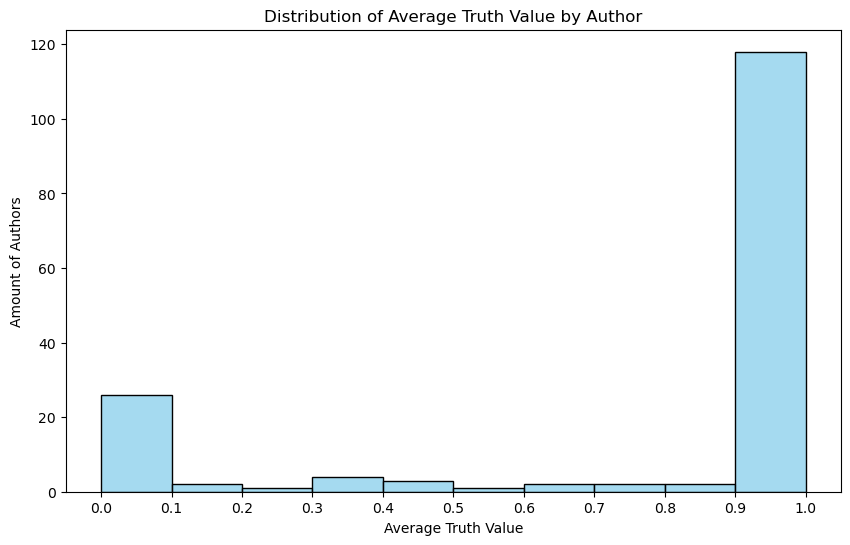

In [43]:
avg_truth_by_author = df.groupby('author')['BinaryNumTarget'].mean().reset_index()
avg_truth_by_author.columns = ['author', 'average_truth_value']

plt.figure(figsize=(10,6))
sns.histplot(avg_truth_by_author['average_truth_value'], bins=10, kde=False, color='skyblue', edgecolor='black')
plt.title("Distribution of Average Truth Value by Author")
plt.xlabel("Average Truth Value")
plt.ylabel("Amount of Authors")
plt.xticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
plt.show()

Distribution of the average truthfulness of each author. This is done by averaging the values in BinaryNumTarget for each unique author (it is 1 in BinaryNumTarget if the tweet is true and then 0 if false). It seems most out of the 161 authors are truthful. Either users are truthful or not very much so based on the histogram distribution. Since we also know there are about equal number of true and false tweets (give or take 3000), this graph suggests that most of the false tweets come from a small amount of deceiving users.

The number of authors per keyword seems to be 1. So not many tweets with the same keywords. Tweets are diverse.

In [34]:
authors_per_keyword = df.groupby('manual_keywords')['author'].nunique().reset_index()
authors_per_keyword.columns = ['manual_keyword', 'num_authors']

# Sort by number of authors
authors_per_keyword = authors_per_keyword.sort_values(by='num_authors', ascending=False)

print(authors_per_keyword)

                                       manual_keyword  num_authors
1055                                              xxx            2
828                           heroin, southern border            2
708            american automobile industry, new jobs            1
695   World Health Organization, ban, drinking, women            1
696                     World War 2, health insurance            1
...                                               ...          ...
357                             Joe Biden,ipad,podium            1
358                     Joe Biden,raise,tax,americans            1
359                              Joe Exotic, pardoned            1
360                    Joe Manchin, commit, Kavanaugh            1
528                            Rouhani, Cabinet, Ph.D            1

[1056 rows x 2 columns]


In [35]:
tweets_per_keyword = df.groupby('manual_keywords')['tweet'].count().reset_index()
tweets_per_keyword.columns = ['manual_keyword', 'num_tweets']
tweets_per_keyword = tweets_per_keyword.sort_values(by='num_tweets', ascending=False)

print(tweets_per_keyword)

                                manual_keyword  num_tweets
773                     congress, millionaires         499
589                  Texas, testing per capita         499
226               Crimea, historically, Russia         499
754                candidates, 2016, unpopular         499
966             science safe teachers students         499
..                                         ...         ...
673      West Virginia, contruction jobs, 2017           1
319    Hawaii, out-of-state, driver's licenses           1
738  bishops, United States, 1919, health care           1
570               Ted Cruz, not led businesses           1
222          Cook county, shut down, 15 months           1

[1056 rows x 2 columns]


## Histogram of number of tweets per keyword


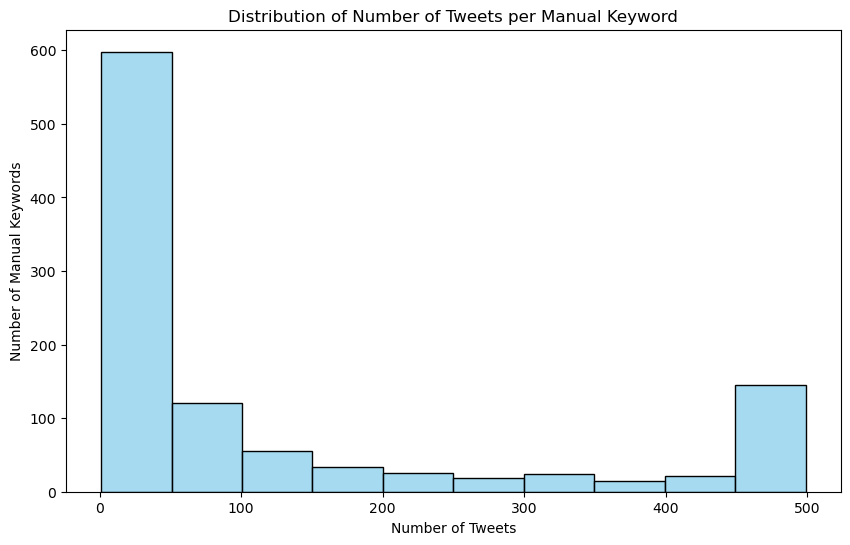

In [37]:
tweets_per_keyword = df.groupby('manual_keywords')['tweet'].count()

plt.figure(figsize=(10,6))
sns.histplot(tweets_per_keyword, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Number of Tweets per Manual Keyword")
plt.xlabel("Number of Tweets")
plt.ylabel("Number of Manual Keywords")
plt.show()

Tweets are mostly spread out by topic/manual keyword. Good for realiable dataset that is not too biased towards one manual keyword/data set.

## Bar plot of tweets by 5 label majority answer

5_label_majority_answer
Agree              54335
Mostly Agree       53806
NO MAJORITY        22605
Mostly Disagree     2891
Disagree             561
Name: count, dtype: int64


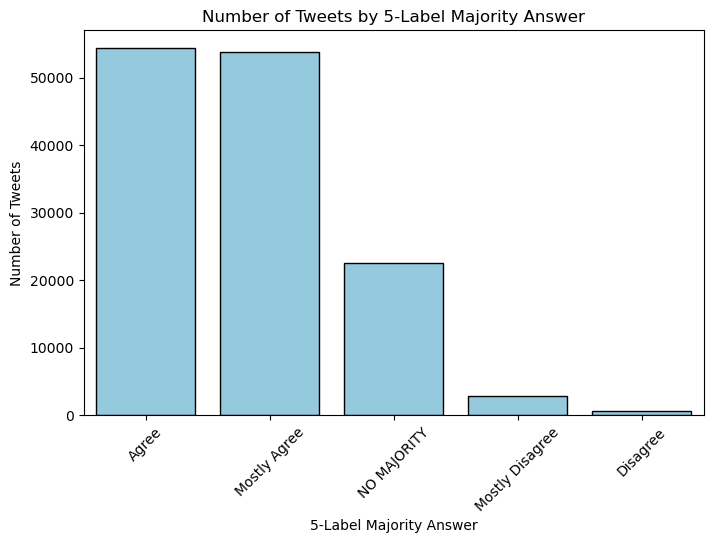

In [44]:
tweets_per_5label = df['5_label_majority_answer'].value_counts()

print(tweets_per_5label)

plt.figure(figsize=(8,5))
sns.barplot(x=tweets_per_5label.index, y=tweets_per_5label.values, color='skyblue', edgecolor='black')
plt.title("Number of Tweets by 5-Label Majority Answer")
plt.xlabel("5-Label Majority Answer")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

Most tweets were authors agreeing with the referenced article.

## Bar plot of tweets by 3 label majority answer

3_label_majority_answer
Agree       128471
Disagree      5727
Name: count, dtype: int64


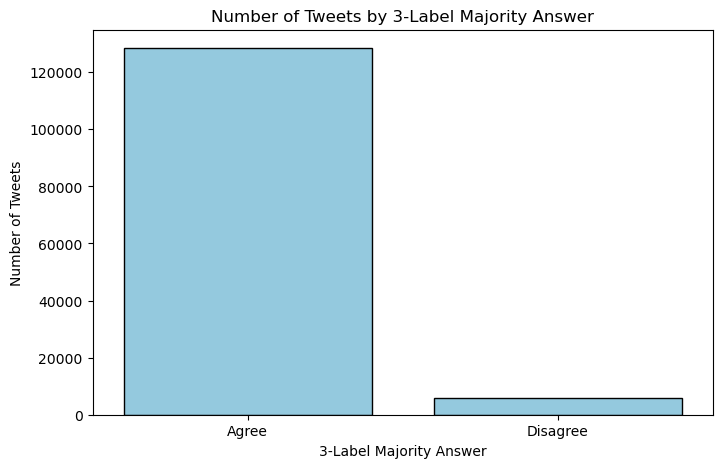

In [47]:
tweets_per_3label = df['3_label_majority_answer'].value_counts()

print(tweets_per_3label)

plt.figure(figsize=(8,5))
sns.barplot(x=tweets_per_3label.index, y=tweets_per_3label.values, color='skyblue', edgecolor='black')
plt.title("Number of Tweets by 3-Label Majority Answer")
plt.xlabel("3-Label Majority Answer")
plt.ylabel("Number of Tweets")
plt.show()

## Truth Value by 3-Label Majority Answer

                         False (0)  True (1)
3_label_majority_answer                     
Agree                        62377     66094
Disagree                      2891      2836


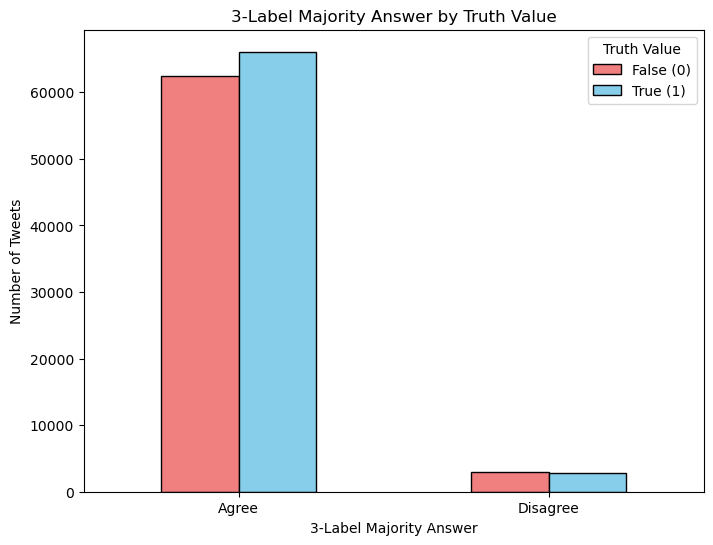

In [54]:
truth_by_3label = pd.crosstab(df['3_label_majority_answer'], df['BinaryNumTarget'])
truth_by_3label.columns = ['False (0)', 'True (1)']

print(truth_by_3label)
truth_by_3label.plot(kind='bar', figsize=(8,6), color=['lightcoral', 'skyblue'], edgecolor='black')
plt.title("3-Label Majority Answer by Truth Value")
plt.xlabel("3-Label Majority Answer")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.legend(title='Truth Value')
plt.show()

Most people, both lying and telling the truth, seem to agree with the article they are talking about in tweets.

## Truth Value by 5-Label Majority Answer

                         False (0)  True (1)
5_label_majority_answer                     
Agree                        26375     27960
Disagree                       315       246
Mostly Agree                 26074     27732
Mostly Disagree               1422      1469
NO MAJORITY                  11082     11523


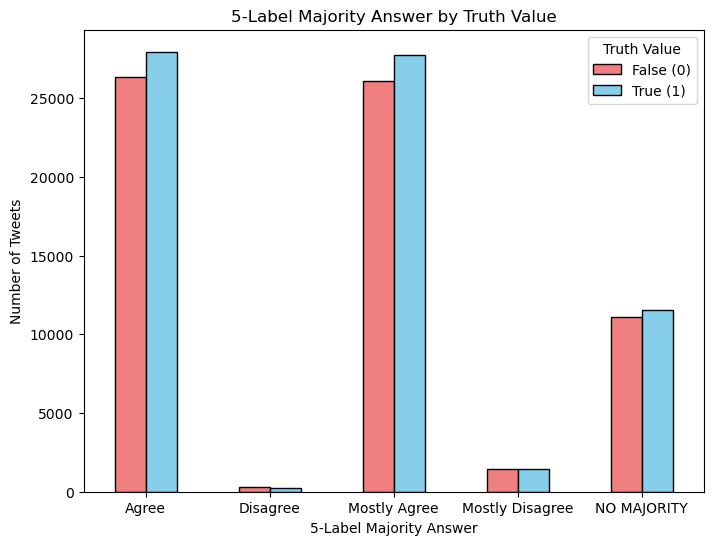

In [56]:
truth_by_5label = pd.crosstab(df['5_label_majority_answer'], df['BinaryNumTarget'])
truth_by_5label.columns = ['False (0)', 'True (1)']

print(truth_by_5label)
truth_by_5label.plot(kind='bar', figsize=(8,6), color=['lightcoral', 'skyblue'], edgecolor='black')
plt.title("5-Label Majority Answer by Truth Value")
plt.xlabel("5-Label Majority Answer")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.legend(title='Truth Value')
plt.show()

The distributions of true and false seem to be the same for all label categories (number true and false are about the same for each label). So it does not seem lying or truthful people have a certain tendency. The only clear trend is that most people agree with articles and rarely disagree in tweets.

## Bar Graphs of number of tweets per author seperated by Low or High Truth Value

In [68]:
tweets_per_author = df.groupby('author')['tweet'].count().reset_index()
tweets_per_author.columns = ['author', 'num_tweets']
author_stats = pd.merge(avg_truth_by_author, tweets_per_author, on='author')

# Step 4: Create two groups based on average truth (low truth and high truth)

group_low_truth = author_stats[(author_stats['average_truth_value'] >= 0) &
                               (author_stats['average_truth_value'] <= 0.1)]

group_high_truth = author_stats[(author_stats['average_truth_value'] >= 0.9) &
                                (author_stats['average_truth_value'] <= 1)]

group_low_truth = group_low_truth.sort_values(by='num_tweets', ascending=False)
group_high_truth = group_high_truth.sort_values(by='num_tweets', ascending=False)

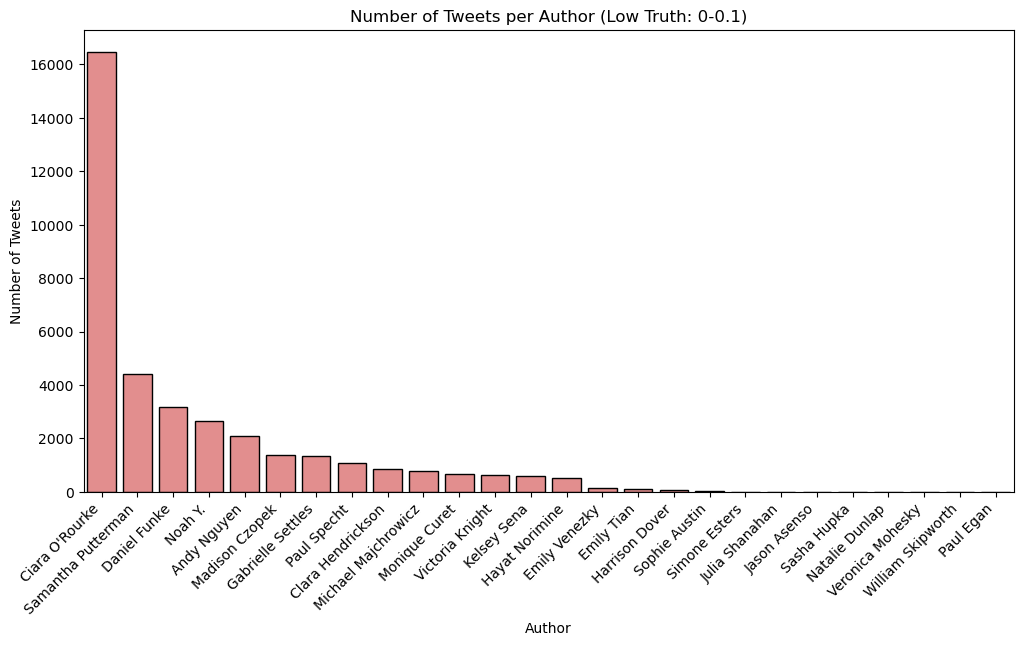

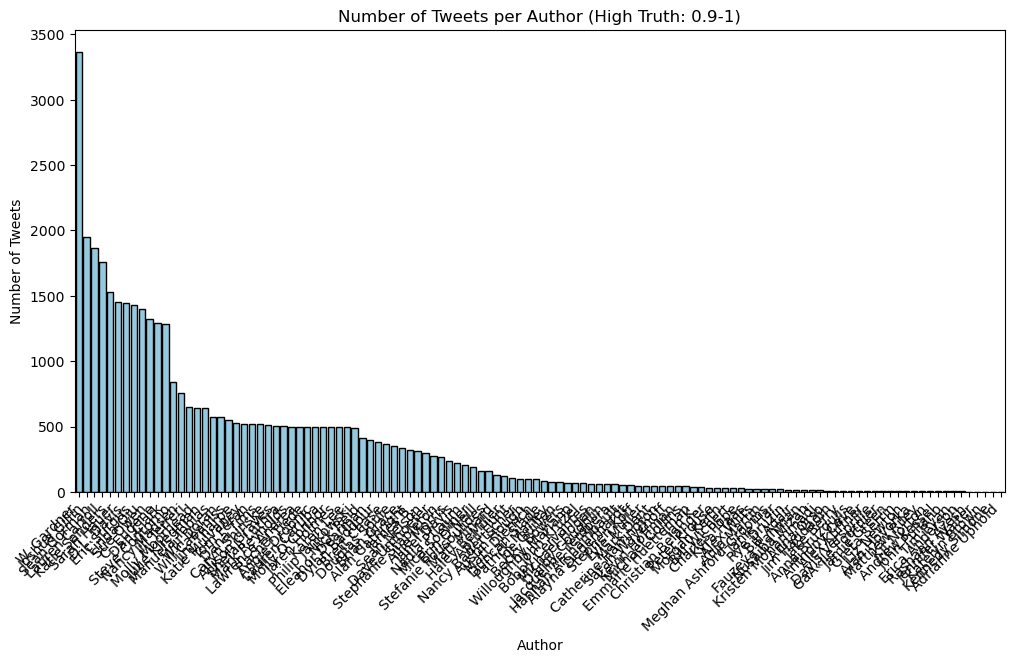

In [69]:
plt.figure(figsize=(12,6))
sns.barplot(x='author', y='num_tweets', data=group_low_truth, color='lightcoral', edgecolor='black')
plt.title("Number of Tweets per Author (Low Truth: 0-0.1)")
plt.xlabel("Author")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x='author', y='num_tweets', data=group_high_truth, color='skyblue', edgecolor='black')
plt.title("Number of Tweets per Author (High Truth: 0.9-1)")
plt.xlabel("Author")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha='right')
plt.show()

Here we can tell there are far less low truth authors and most tweets are from a small pool of individuals who are pumping out up to 4-5 times the amount of the tweets than the users who are telling the truth. It is very staggering that the low truth graph goes up to 16,000 tweets per author while the high truth graph only goes up to 3500.

Ideas:  
1. since we have tweets, we can look for how many times people have used
- quotes (""),
- used hashtags,
- question mark(?),
- exclamation points (!),
- commas (,),
- periods (.),
- percentage (%),
- average length of word in tweets
we can do this for each low truth and high truth group to see if there are differences  

2. we can also analyze the statements (article headlines) to see why people are talking about it or maybe some headlines have more low truth individuals commenting about it, scan headlines for
- ?, !
- "est" superlatives bc they're provocative for headlines so that may entice more low truth people
- average length of words in headline

3. analyze the author names?
- idk if this counts as racism or so but we could analyze which kinds of names are common like people often say republican coded names are like "Mckayleigh"

### Prediction
Could be based off of trends found in ideas 1 & 2 (so combination of language found in tweets and headlines the tweet is talking about)
